In [1]:
! git clone https://github.com/ayanokojix21/NeuroFormer.git

Cloning into 'NeuroFormer'...
remote: Enumerating objects: 268, done.
remote: Counting objects: 100% (268/268), done.
remote: Compressing objects: 100% (205/205), done.
remote: Total 268 (delta 88), reused 225 (delta 53), pack-reused 0 (from 0)
Receiving objects: 100% (268/268), 17.11 MiB | 20.18 MiB/s, done.
Resolving deltas: 100% (88/88), done.
Filtering content: 100% (5/5), 653.55 MiB | 44.46 MiB/s, done.


In [2]:
project_path = "/content/NeuroFormer"

In [3]:
import sys
sys.path.append(project_path)

In [4]:
# Importing Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from transformers import PreTrainedTokenizerFast
import os
import matplotlib.pyplot as plt

In [5]:
from models.NeuroFormer import NeuroFormer # Importing the core Model
from dataloader.lm_loader import get_lm_dataloader # Importing the Dataloader Function to load dataset efficiently
tokenizer = PreTrainedTokenizerFast.from_pretrained(f"{project_path}/tokenizers/lm/") # Loading the Pretrained LM Tokenizer

In [6]:
# Setting Device to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [7]:
# For Reproducability
torch.manual_seed(42)
torch.cuda.manual_seed(42)

In [8]:
vocab_size = tokenizer.vocab_size
vocab_size, len(tokenizer)

(8000, 8000)

In [9]:
# Model HyperParameters
mode = 'decoder_only'
vocab_size = 8000
sequence_length = 256
d_model = 256
num_heads = 4
hidden = 4 * d_model
num_layers = 6
drop_prob = 0.2

In [10]:
# Training HyperParameters
batch_size = 64
total_steps = 8000
lr = 2e-4
best_model_path = 'models/pretraining.pt'
os.makedirs('models/', exist_ok = True)

In [11]:
# Data Path
train_path = f'{project_path}/data/tokenized/Language Modelling/train.pt'
valid_path = f'{project_path}/data/tokenized/Language Modelling/valid.pt'

In [12]:
# Building Up Encoder Only Model
model = NeuroFormer(
    mode=mode,
    vocab_size=vocab_size,
    sequence_length=sequence_length,
    d_model=d_model,
    num_heads=num_heads,
    hidden=hidden,
    num_layers=num_layers,
    drop_prob=drop_prob
).to(device)

In [13]:
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 10,490,176


In [14]:
# Dataset for training and validation
train_loader = get_lm_dataloader(train_path, batch_size=batch_size, shuffle=True)
valid_loader = get_lm_dataloader(valid_path, batch_size=batch_size, shuffle=False)

In [15]:
# Defining Optimizer, scheduler and Criterion
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.convert_tokens_to_ids("<pad>"))

lr_scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=1,
    threshold=1e-4,
    min_lr=1e-6
)

In [16]:
def eval(model, dataloader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            # Creating labels from input_ids
            labels = input_ids.clone()
            decoder_input_ids = input_ids[:, :-1]
            target = labels[:, 1:]
            decoder_attention_mask = attention_mask[:, :-1]

            logits = model(decoder_input_ids, decoder_attention_mask)
            loss = criterion(logits.view(-1, logits.size(-1)), target.reshape(-1))
            total_loss += loss.item()

    return total_loss / len(dataloader)

In [17]:
train_losses, val_losses, val_steps = [], [], []

In [18]:
def train_model():
    model.train()
    best_val_loss = float('inf')
    step = 0

    while step < total_steps:
        for batch in train_loader:

            if step >= total_steps:
                break

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            # Creating labels from input_ids
            labels = input_ids.clone()
            decoder_input_ids = input_ids[:, :-1]
            target = labels[:, 1:]
            decoder_attention_mask = attention_mask[:, :-1]

            optimizer.zero_grad()

            logits = model(decoder_input_ids, decoder_attention_mask)
            loss = criterion(logits.view(-1, logits.size(-1)), target.reshape(-1))
            loss.backward()
            optimizer.step()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            train_losses.append(loss.item())

            if step % 200 == 0 or step == total_steps - 1:
                avg_val_loss = eval(model, valid_loader)
                val_losses.append(avg_val_loss)
                val_steps.append(step)
                model.train()

                print(f"Step {step}: Train Loss: {loss.item():.4f}, Val Loss = {avg_val_loss:.4f}")

                prev_lr = optimizer.param_groups[0]['lr']
                lr_scheduler.step(avg_val_loss)
                new_lr = optimizer.param_groups[0]['lr']
                if new_lr != prev_lr:
                    print(f"Learning rate reduced to {new_lr:.6f}")

                if avg_val_loss < best_val_loss:
                    best_val_loss = avg_val_loss
                    torch.save(model.state_dict(), best_model_path)
                    print(f"Best model saved at step {step}")

            step += 1

In [19]:
train_model()

Step 0: Train Loss: 9.1439, Val Loss = 8.8303
Best model saved at step 0
Step 200: Train Loss: 6.2098, Val Loss = 6.2245
Best model saved at step 200
Step 400: Train Loss: 5.8122, Val Loss = 5.7389
Best model saved at step 400
Step 600: Train Loss: 5.4987, Val Loss = 5.4948
Best model saved at step 600
Step 800: Train Loss: 5.3901, Val Loss = 5.3308
Best model saved at step 800
Step 1000: Train Loss: 5.2462, Val Loss = 5.2125
Best model saved at step 1000
Step 1200: Train Loss: 5.1771, Val Loss = 5.1112
Best model saved at step 1200
Step 1400: Train Loss: 4.9836, Val Loss = 5.0281
Best model saved at step 1400
Step 1600: Train Loss: 4.8939, Val Loss = 4.9587
Best model saved at step 1600
Step 1800: Train Loss: 5.1404, Val Loss = 4.9032
Best model saved at step 1800
Step 2000: Train Loss: 5.0435, Val Loss = 4.8398
Best model saved at step 2000
Step 2200: Train Loss: 4.7072, Val Loss = 4.7887
Best model saved at step 2200
Step 2400: Train Loss: 4.8932, Val Loss = 4.7459
Best model saved 

In [20]:
def visualize(train_losses, val_losses, val_steps):
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_steps, val_losses, label='Val Loss')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()

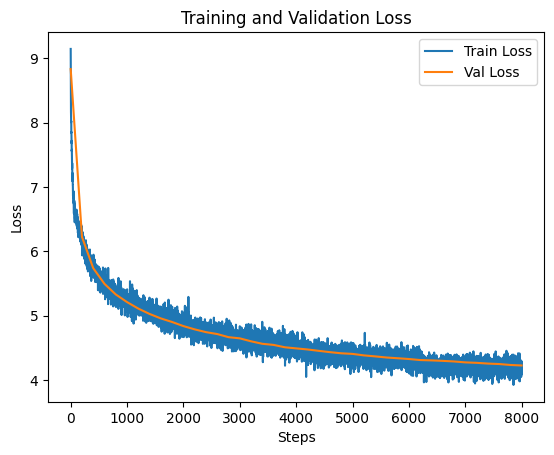

In [21]:
visualize(train_losses, val_losses, val_steps)